In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
# data = pd.read_csv('diabetes.csv')
# print(data.shape)

# y = data['Outcome'].values  # Extract target
# X = data.drop('Outcome', axis=1).values  # Extract features

# # Add bias term (column of 1s)
# bias = np.ones((X.shape[0], 1))
# X = np.concatenate([X, bias], axis=1)  # Use concatenate, not concatanate

# print(f'X shape: {X.shape}')
# print(f'y shape: {y.shape}')

In [14]:
# data.head()

In [15]:
# from sklearn.preprocessing import StandardScaler

# # scale features to same scale (standardization) and keep the bias column if present

# # keep a copy of original X
# X_orig = X.copy()

# # detect & separate bias column (assumed constant 1s in last column)
# if np.allclose(X[:, -1], 1.0):
#     features, bias_col = X[:, :-1], X[:, -1:].copy()
# else:
#     features, bias_col = X, None

# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features)

# # reconstruct X (preserve bias column if it existed)
# if bias_col is not None:
#     X = np.concatenate([features_scaled, bias_col], axis=1)
# else:
#     X = features_scaled

# # quick sanity checks
# print("X shape:", X.shape)
# print("First row (scaled):", X[0])
# print("Per-feature mean (approx 0):", np.round(np.mean(X[:, :features_scaled.shape[1]], axis=0), 6))
# print("Per-feature std  (approx 1):", np.round(np.std(X[:, :features_scaled.shape[1]], axis=0), 6))

In [16]:
num_obs = 5000

# # Generate random x1 and x2 values between -1 and 1
x1 = np.random.uniform(-1, 1, size=num_obs)
x2 = np.random.uniform(-1, 1, size=num_obs)

# # Add bias term (column of 1s)
bias = np.ones(num_obs)

# # Stack into feature matrix: [x1, x2, bias]
X = np.column_stack([x1, x2, bias])

# # ============ CHOOSE ONE PATTERN BELOW ============

# # 1. Circle pattern (Easy)
# # y = (np.sqrt(x1**2 + x2**2) < 0.75).astype(int)

# # 2. XOR pattern (Medium - Classic non-linear)
# # y = ((x1 * x2) > 0).astype(int)

# # #3. Spiral pattern (Hard)
# # theta = np.arctan2(x2, x1)
# # r = np.sqrt(x1**2 + x2**2)
# # y = ((np.sin(theta * 3) * r) > 0).astype(int)

# # 4. Checkerboard pattern (Hard)
# y = (((x1 > 0) & (x2 > 0)) | ((x1 < 0) & (x2 < 0))).astype(int)

# # 5. Double circle (Medium)
# # r = np.sqrt(x1**2 + x2**2)
# # y = ((r < 0.4) | ((r > 0.6) & (r < 0.9))).astype(int)

# # 6. Four corners (Medium)
# # y = ((np.abs(x1) > 0.5) & (np.abs(x2) > 0.5)).astype(int)

# # 7. Heart shape (Hard)
# # y = ((x1**2 + (x2 - np.abs(x1)**0.5)**2) < 0.5).astype(int)

#8. Star pattern (Very Hard)
theta = np.arctan2(x2, x1)
r = np.sqrt(x1**2 + x2**2)
y = (r < (0.5 + 0.3 * np.cos(5 * theta))).astype(int)

# # 9. Sine wave boundary (Medium-Hard)
# # y = (x2 < np.sin(x1 * np.pi * 3) * 0.5).astype(int)

# # # 10. Complex multi-shape (Very Hard)
# # circle1 = (np.sqrt((x1 - 0.5)**2 + (x2 - 0.5)**2) < 0.3)
# # circle2 = (np.sqrt((x1 + 0.5)**2 + (x2 + 0.5)**2) < 0.3)
# # square = (np.abs(x1) < 0.3) & (np.abs(x2) < 0.3)
# # y = (circle1 | circle2 | square).astype(int)

# print(f'X shape: {X.shape}')
# print(f'y shape: {y.shape}')
# print(f'Class 0 (outside): {np.sum(y==0)} samples')
# print(f'Class 1 (inside): {np.sum(y==1)} samples')

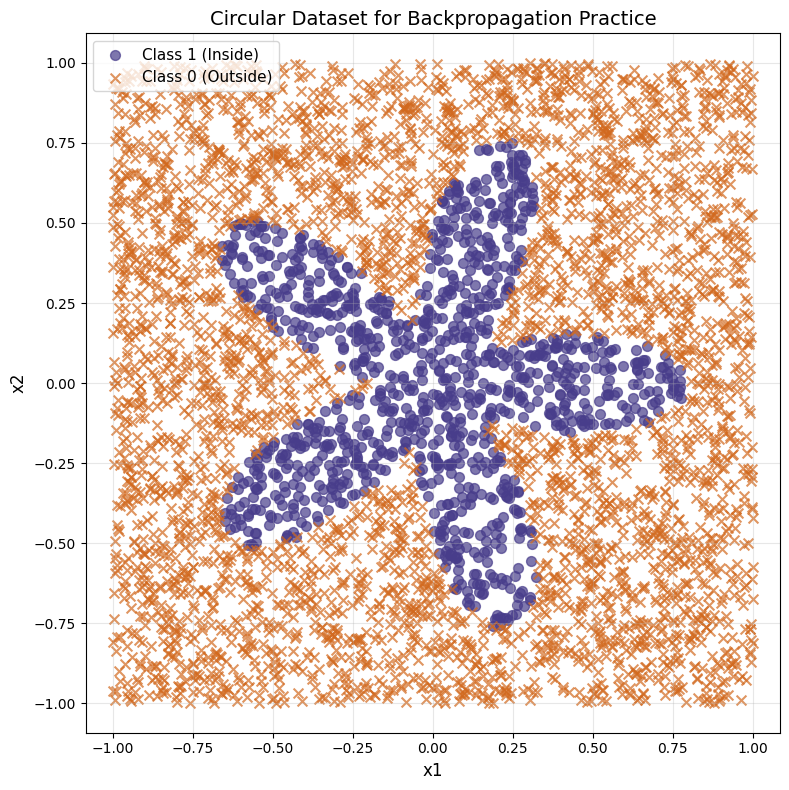

In [17]:
# Visualize the circular dataset
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[y==1, 0], X[y==1, 1], c='darkslateblue', marker='o', s=50, alpha=0.7, label='Class 1 (Inside)')
ax.scatter(X[y==0, 0], X[y==0, 1], c='chocolate', marker='x', s=50, alpha=0.7, label='Class 0 (Outside)')
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Circular Dataset for Backpropagation Practice', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

Defining Sigmoid function

In [18]:
def sigmoid(x):
    return 1.0/(1.0 + np.exp(-x))

Defining loss funciton

In [19]:
def loss_func(y_true, y_pred, eps=1e-16):
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1-y_true) * np.log(1-y_pred))) / len(y_true)

Plottig loss and accuracy

In [20]:
def plot_loss_accuracy(loss_vals, accuracies):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over iterations')
    
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(loss_vals)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Log Loss')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(accuracies)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Accuracy');

Defining the forword passing function

In [21]:
def forward_pass_N_gradients(W1, W2, y_true):
    #calculation for the first hidden layer
    Z_1 = np.dot(X, W1)
    a_1 = sigmoid(Z_1)
    #print(a_1.shape)
    #calculation for the second hidden layer
    Z_2 = np.dot(a_1, W2)
    y_pred = sigmoid(Z_2)

    #calculating gradients for W1 and W2
    grad_W2 = np.dot((-y_true + y_pred),a_1)
    #print(grad_W2.shape)
    #(-y_true + y)^.W2, shape (500,1).(1,2) = (500, 2)
    temp_1 = np.dot((-y_true+ y_pred).reshape(-1,1), W2.reshape(-1,1).T)
    #print(temp_1.shape)
    #(1-a2)*a2, shape (500,2)
    temp_2 = (1-a_1)*a_1
    #(-y_true + y).W2*(a*(1-a)), shape (500, 2)
    temp_1 = temp_1*temp_2
    #print(temp_1.shape)
    # (-y_true + y)^.W2.a*(1-a)* X^, shape (3, 2)
    grad_W1 = np.dot(X.T, temp_1)
    #print(grad_W1.shape)

    return  y_pred, (grad_W1, grad_W2)


Taking random values for both(two) hidden layers' weights. 

In [ ]:
def back_propagation():
   mx_epoch, mx_acc=0, 0
   total_epoch = 3000
   learning_rate = 0.001
   num_of_nodes = 14
   W1 = np.random.uniform(-1, 1, size=(X.shape[1], num_of_nodes))
   W2 = np.random.uniform(-1,1, size=(num_of_nodes,) )

   loss_vals, accuracies = [], []
   for i in range(total_epoch):
      y_pred, (grad_W1, grad_W2) = forward_pass_N_gradients(W1, W2, y)
      loss_ = loss_func(y, y_pred)
      loss_vals.append(loss_)
      acc = np.sum((y_pred>=.5) == y)/X.shape[0]
      accuracies.append(acc)
      if mx_acc< acc:
         mx_acc = acc
         mx_epoch = i

      W1 = W1 - learning_rate*grad_W1
      W2 = W2 - learning_rate*grad_W2
   
   print((mx_acc, mx_epoch))
   plot_loss_accuracy(loss_vals, accuracies)

   return y_pred


In [23]:
def visualize_predictions(y_pred, y_true, X):
    """
    Visualize the predictions vs ground truth
    """
    # Convert predictions to binary (0 or 1)
    pred_binary = (y_pred >= 0.5).astype(int)
    
    # Create prediction masks
    correct_class1 = (pred_binary == 1) & (y_true == 1)  # True positives
    correct_class0 = (pred_binary == 0) & (y_true == 0)  # True negatives
    wrong_class1 = (pred_binary == 1) & (y_true == 0)    # False positives
    wrong_class0 = (pred_binary == 0) & (y_true == 1)    # False negatives
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot correct predictions
    ax.scatter(X[correct_class1, 0], X[correct_class1, 1], 
               c='darkslateblue', marker='o', s=50, alpha=0.7, 
               label=f'True Positives ({np.sum(correct_class1)})')
    ax.scatter(X[correct_class0, 0], X[correct_class0, 1], 
               c='chocolate', marker='x', s=50, alpha=0.7, 
               label=f'True Negatives ({np.sum(correct_class0)})')
    
    # Plot incorrect predictions with larger markers
    if np.sum(wrong_class1) > 0:
        ax.scatter(X[wrong_class1, 0], X[wrong_class1, 1], 
                   c='red', marker='s', s=150, alpha=0.6, 
                   edgecolors='black', linewidths=2,
                   label=f'False Positives ({np.sum(wrong_class1)})')
    if np.sum(wrong_class0) > 0:
        ax.scatter(X[wrong_class0, 0], X[wrong_class0, 1], 
                   c='yellow', marker='D', s=150, alpha=0.6, 
                   edgecolors='black', linewidths=2,
                   label=f'False Negatives ({np.sum(wrong_class0)})')
    
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('Neural Network Predictions vs Ground Truth', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

(np.float64(0.9722), 29702)


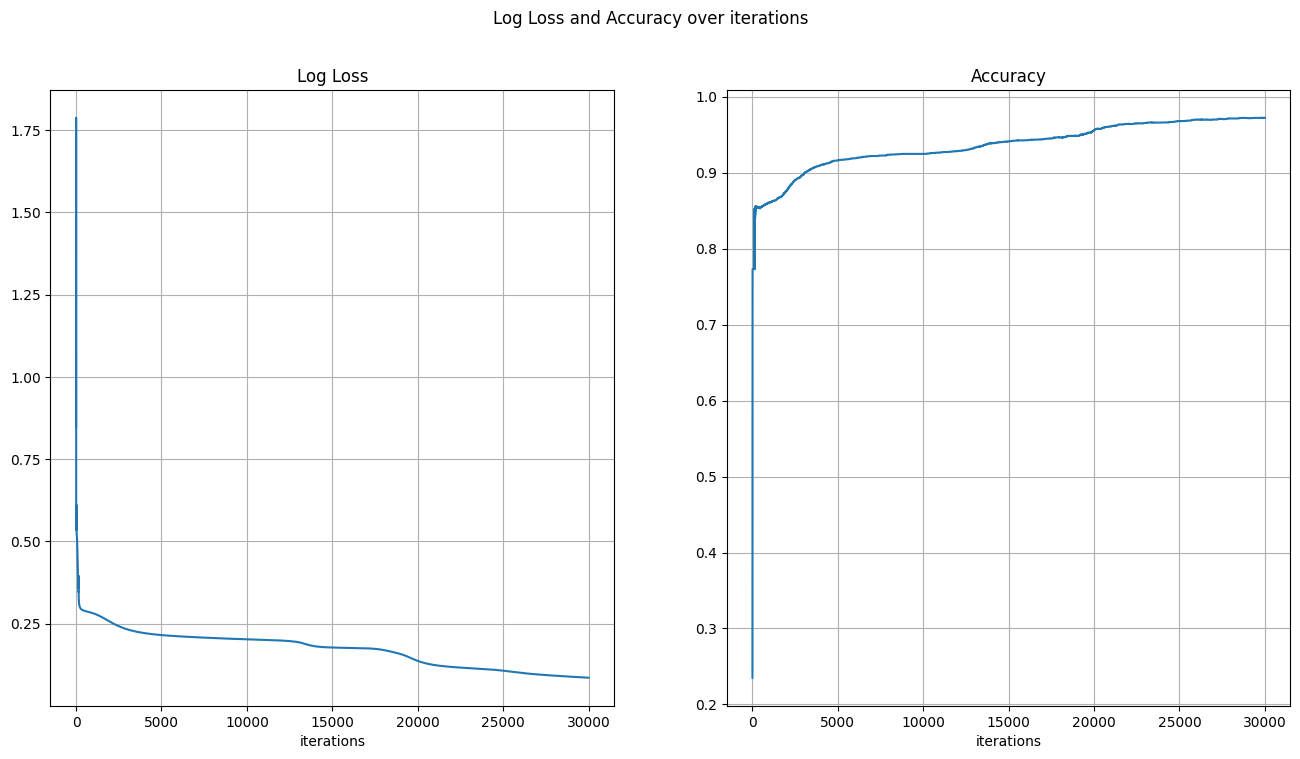

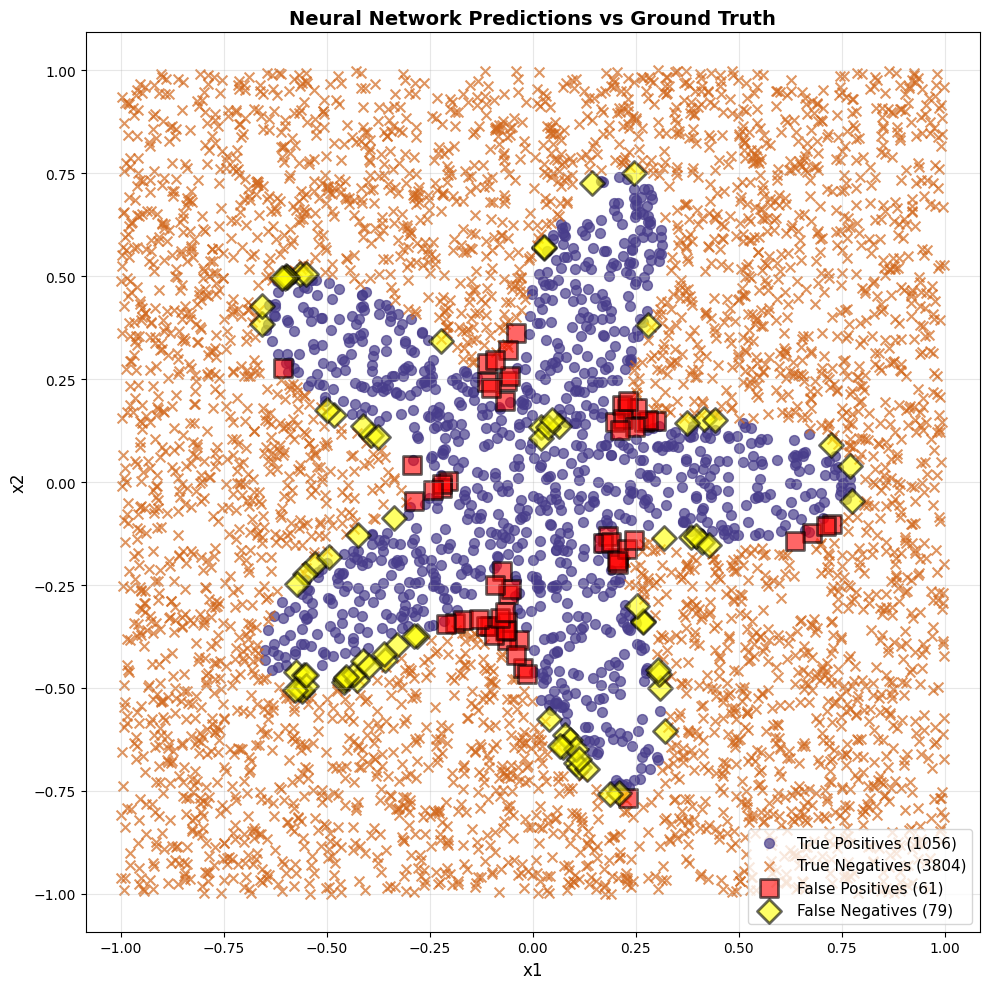

In [24]:
y_pred = back_propagation()
visualize_predictions(y_pred, y, X)